**Following solution is on Heart dataset where I have tried to predict whether a person may have or have not heart ailment
based on historical data. We have used some models to predict the same.**

*NumPy is a library for Python that is used for working with arrays, matrices.
Pandas is used for data analysis and creating dataframes in tabular form .
Selecting a proper model allows you to generate accurate results.train_test_split() is used to get training and test sets.
tree- decision trees illustrate all possible outcomes of a decision. It is used to make predictions based on how a previous set of questions were answered.
accuracy_score- In Python, the accuracy_score function of the sklearn. metrics package calculates the accuracy score for a set of predicted labels against the true labels.
confusion_matrix- A confusion matrix is a summary of prediction results on a classification problem. A classification problem is when the output variable is a category, such as “red” or “blue” or “disease” and “no disease”.
Seaborn is a library used to plot graphs. It is used to visualize random distributions.
Matplotlib is a python library used to create 2D graphs and plots by using python scripts. Matplotlib works efficiently with data frames and arrays.*

*Please note: all the definitions are from 'Google' with small changes as per requirement.*



In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Steps for creating Machine Learning Algorithm for prediction
1. Analyzing the data
2. Cleaning the data
3. Building the model
4. train
5. test

In [2]:
import warnings
warnings.filterwarnings('ignore') # this is used to disable python warnings

In [3]:
df = pd.read_csv("../input/heart-disease-dataset/heart.csv") #this is used to read the csv file using pandas and creating a dataframe

In [4]:
df.head() #this will show first five rows. To see the entire data frame type df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.shape #this is used to check number of rows and columns

(303, 14)

In [6]:
df.info() # this is used to check the type of entries. Like, integer, float, object, null count.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.dtypes # is used to check data types, integer, float, etc.

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [8]:
df.isnull().sum() #is used to check the null value counts. You can also try this without sum to check the result. isnull or isna gives the same result.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.describe() #describe function is used to get a descriptive statistics summary of a given dataframe. This includes mean, count, std deviation, percentiles, and min-max values of all the features.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


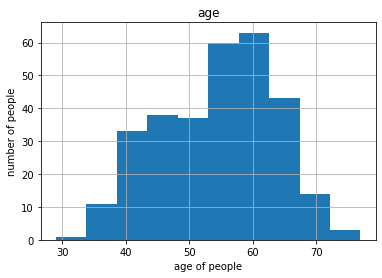

In [10]:
df['age'].hist() #drawing histogram to visualize age distribution.
plt.title('age') #title of the histogram
plt.xlabel('age of people') #x axis
plt.ylabel('number of people') # y axis
plt.show()

Ploting distplot

It is used for univariant set of observations and visualizes it through a histogram i.e. only one observation and hence we choose one particular column of the dataset.A distribution plot displays a distribution and range of a set of numeric values plotted against a dimension

<AxesSubplot:xlabel='age', ylabel='Density'>

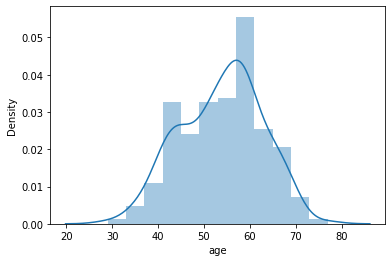

In [11]:
sns.distplot(df[df['sex']==1] ['age']) # 1 is for male

<AxesSubplot:xlabel='age', ylabel='Density'>

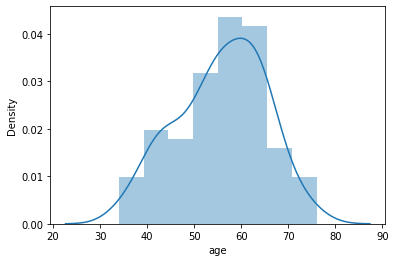

In [12]:
sns.distplot(df[df['sex']==0] ['age']) #0 is for female

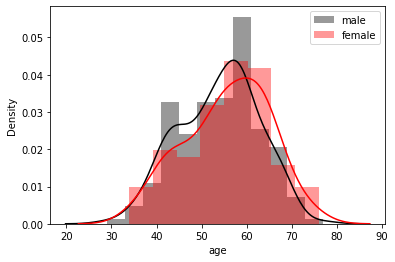

In [13]:
#plotting above two charts together
sns.distplot(df[df['sex']==1]['age'],label='male',color='black')
sns.distplot(df[df['sex']==0]['age'],label='female',color='red')
plt.legend()

Countplot-
It counts the number of observations per category for a categorical variable, and displays the results as a bar chart.

<AxesSubplot:xlabel='target', ylabel='count'>

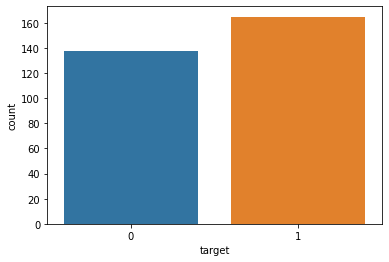

In [14]:
sns.countplot(x = 'target', data= df) #Here it is counting the number in target column and drawing histogram.

In [15]:
df['target'].value_counts() #counting the target value in numbers.

1    165
0    138
Name: target, dtype: int64

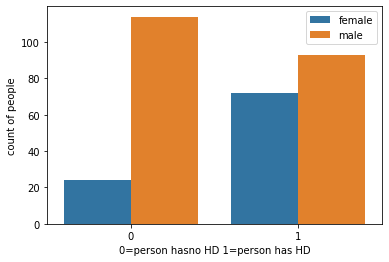

In [16]:
sns.countplot(x='target', hue='sex', data=df) # hue parameter determines which column in the data frame should be used for colour encoding
plt.xlabel('0=person hasno HD 1=person has HD')
plt.ylabel('count of people')
plt.legend(['female','male'])

**train_test_split**
*The train-test split is used to estimate the performance of machine learning algorithms that are applicable for prediction.
Please note: train part should be more than test part.*

* From the heart dataset we are now dropping the target cloumn and storing the remaining independent variables in x.
Also, we are storing the target column in y variable. By doing this we are splitting the data into x and y. Elaborating it further we may say-
* independent features, called (x).
* dependent variables, called (y).
To split it, we do:

x Train – x Test / y Train – y Test
x Train and y Train become data for the machine learning, capable to create a model.

Once the model is created, input x Test and the output should be equal to y Test. *

In [17]:
x = df.drop(columns=['target']) #dropping target column from dataframe df.

In [18]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [19]:
y = df['target'] #assigining target column in y.

In [20]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [21]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=0)# Here, first we write x train and infront of that we have y train, in the next line we have x test and infront of that we have ytest. Test size is 0.3 that means test is 30 % whereas train is 70%.

*random_state- controls the shuffling process. 
With random_state=None , we get different train and test sets across different executions and the shuffling process is out of control. With random_state=0 , we get the same train and test sets across different executions.*

*Decision tree is a type of supervised learning algorithm that can be used for both regression and classification problems. 
The algorithm uses training data to create rules. The algorithm uses training data to create rules that can be represented by a tree structure.*

In [22]:
model=tree.DecisionTreeClassifier()

*The fit() method takes the training data as arguments, which can be one array in the case of unsupervised learning, or two arrays in the case of supervised learning.
Note that the model is fitted using X and y. X and y are two example variable.*

In [23]:
model.fit(xtrain,ytrain)

DecisionTreeClassifier()

*Predict Method Predicts an Output.  it provides a set of tools for doing things like training and evaluating machine learning models. Once the model is trained then it starts predictions.*

In [24]:
y_predict=model.predict(xtest) #y_predict is the result of xtest

*The accuracy_score method is used to calculate the accuracy of count of correct prediction. it represents the ratio of the sum of true positives and true negatives out of all the predictions.
Accuracy Score = (TP+TN)/ (TP+FN+TN+FP)*

In [25]:
accuracy_score(ytest,y_predict)

0.7142857142857143

Now we will check the above score with confusion matrix

*Confusion matrix- A confusion matrix is a tabular summary of the number of correct and incorrect predictions made by a classifier.
It can be used to evaluate the performance of a classification model through the calculation of performance metrics.*

In [26]:
confusion_matrix(ytest,y_predict)

array([[33, 11],
       [15, 32]])

In [27]:
32 + 36 # adding true negative and true positive 

68

In [28]:
(32 + 36)/ (32 + 12 + 33+ 14)

0.7472527472527473

#Finding accuracy score
Correct prediction divided by total number of prediction.

#Correct prediction from confusion matrix is 32 + 33

In [29]:
(32 + 33)/ (32 + 33+ 11+ 11)

0.7471264367816092

*Finding f1 score-
F1 score is defined as the harmonic mean between precision and recall. It is used as a statistical measure to rate performance. In other words, an F1-score (from 0 to 9, 0 being lowest and 9 being the highest) is a mean of an individual's performance, based on two factors i.e. precision and recall. It is the most accurate way of finding accuracy*

*recall_score- The recall is the ratio tp / (tp + fn) where tp is the number of true positives and fn the number of false negatives.
The recall is intuitively the ability of the classifier to find all the positive samples.
Models need high recall when you need output-sensitive predictions.
For example, predicting cancer or predicting terrorists needs a high recall, in other words, you need to cover false negatives as well.
It is ok if a non-cancer tumor is flagged as cancerous but a cancerous tumor should not be labeled non-cancerous.*

*Precision - Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. The question that this metric answer is of all passengers that labeled as survived, how many actually survived? 
High precision relates to the low false positive rate.*

In [30]:
#f1 score = (2*precision*recall)/(precision+recall)

In [31]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [32]:
precision_score(ytest,y_predict)

0.7441860465116279

In [33]:
recall_score(ytest,y_predict)

0.6808510638297872

In [34]:
f1_score(ytest,y_predict)

0.711111111111111

Thank you